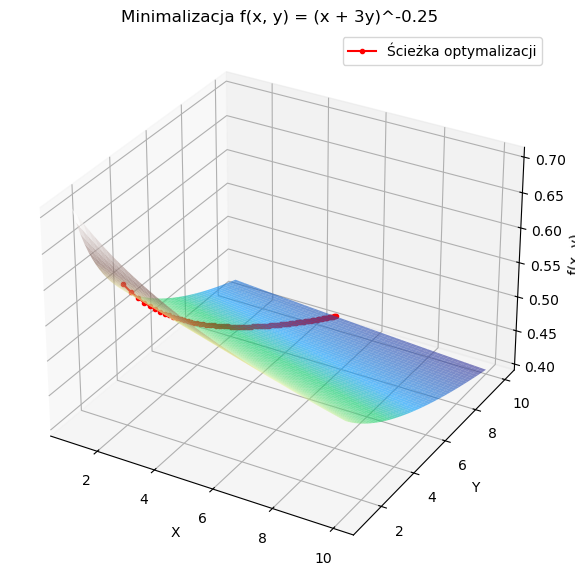

Znalezione minimum przybliżone: (4.68, 10.00)
Wartość funkcji w tym punkcie: 0.4121


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

def f(x, y):
    return (x + 3*y)**(-0.25)

def gradient(x, y):
    df_dx = -0.25 * (x + 3*y)**(-1.25)
    df_dy = -0.75 * (x + 3*y)**(-1.25)
    return np.array([df_dx, df_dy])

x, y = 2.0, 2.0  # Punkt startowy wewnątrz przedziału [1, 10]
lr = 5.0 # Learning rate (dość duży, bo gradienty są bardzo małe)
epochs = 100
history = [[x, y]]

for _ in range(epochs):
    grad = gradient(x, y)
    x = x - lr * grad[0]
    y = y - lr * grad[1]
    
    # Utrzymanie punktu w przedziale [1, 10]
    x = np.clip(x, 1, 10)
    y = np.clip(y, 1, 10)
    history.append([x, y])

history = np.array(history)

fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

X_range = np.linspace(1, 10, 50)
Y_range = np.linspace(1, 10, 50)
X, Y = np.meshgrid(X_range, Y_range)
Z = f(X, Y)

surf = ax.plot_surface(X, Y, Z, cmap='terrain', alpha=0.6)
ax.plot(history[:, 0], history[:, 1], f(history[:, 0], history[:, 1]), 
        color='red', marker='o', markersize=3, label='Ścieżka optymalizacji')

ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('f(x, y)')
ax.set_title('Minimalizacja f(x, y) = (x + 3y)^-0.25')
plt.legend()
plt.show()

print(f"Znalezione minimum przybliżone: ({x:.2f}, {y:.2f})")
print(f"Wartość funkcji w tym punkcie: {f(x, y):.4f}")

In [2]:
import numpy as np

def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def sigmoid_derivative(x):
    return sigmoid(x) * (1 - sigmoid(x))

X = np.array([[0.1, 0.2]])
Y_true = np.array([[1.0]])

W1 = np.random.randn(2, 3)
b1 = np.zeros((1, 3))
# Warstwa 2: 3 neurony -> 1 wyjście
W2 = np.random.randn(3, 1)
b2 = np.zeros((1, 1))

z1 = np.dot(X, W1) + b1
a1 = sigmoid(z1)
z2 = np.dot(a1, W2) + b2
a2 = sigmoid(z2)

error_output = a2 - Y_true
delta2 = error_output * sigmoid_derivative(z2)

dW2 = np.dot(a1.T, delta2)
db2 = delta2

delta1 = np.dot(delta2, W2.T) * sigmoid_derivative(z1)

dW1 = np.dot(X.T, delta1)
db1 = delta1

print("Gradienty warstwy wyjściowej dW2:\n", dW2)
print("Gradienty warstwy ukrytej dW1:\n", dW1)

Gradienty warstwy wyjściowej dW2:
 [[-0.02168574]
 [-0.01659417]
 [-0.01739022]]
Gradienty warstwy ukrytej dW1:
 [[-0.00218612  0.0006651  -0.00046693]
 [-0.00437224  0.0013302  -0.00093386]]
